<a href="https://colab.research.google.com/github/Rageel-28/244107020136-Machine-Learning/blob/main/JS04/JS04_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Langkah 1 - Persiapan Data

Download dan letakkan file data yang akan digunakan pada direktori yang sama. Pastikan data telah disimpan dalam format CSV (`dataset.csv`).

## Langkah 2 - Import Library

In [1]:
# import package
import numpy as np
import pandas as pd


## Langkah 3 - Baca Data

In [2]:
# baca data dari file CSV
data = pd.read_csv('dataset.csv')


## Langkah 4 - Pemahaman Terhadap Data

In [3]:
# melihat beberapa data awal
data.head()


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\r\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\r\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\r\nCobbborough,...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\r\nPort Jason, OH 22070-...",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\r\nPort Jacobville, PR...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [4]:
# mengecek ukuran data
data.shape


(500, 8)

In [5]:
# informasi tentang data
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [6]:
# deskripsi data
data.describe()


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


## Langkah 5 - Visualisasi Data

In [7]:
# import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns


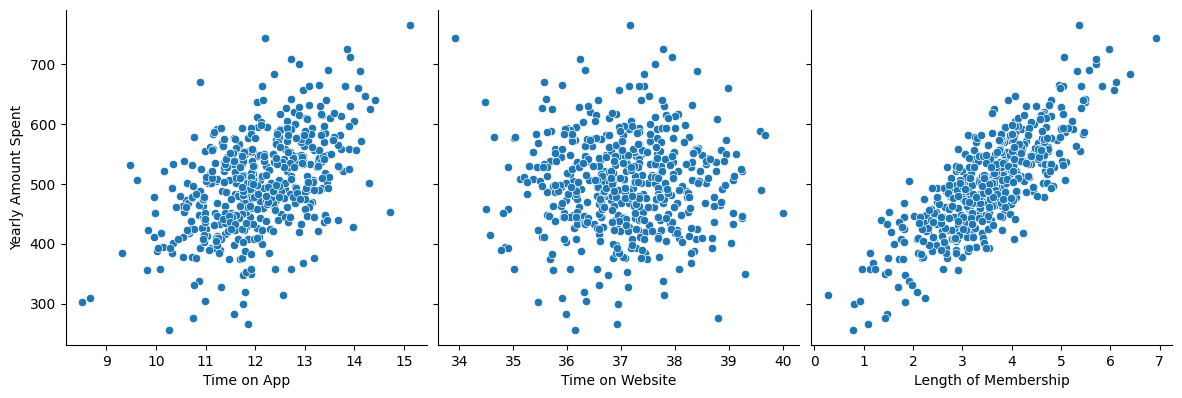

In [8]:
# visualisasi data dengan pairplot
sns.pairplot(
    data,
    x_vars=['Time on App', 'Time on Website', 'Length of Membership'],
    y_vars='Yearly Amount Spent',
    height=4, aspect=1, kind='scatter'
)
plt.show()


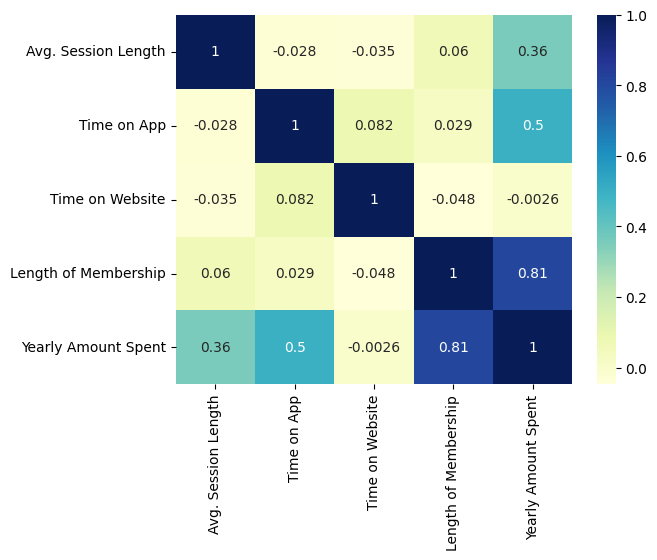

In [9]:
# visualisasi korelasi dengan heatmap
sns.heatmap(data.corr(numeric_only=True), cmap='YlGnBu', annot=True)
plt.show()


## Langkah 6 - Regresi Linier

Berdasarkan hasil korelasi pada heatmap, pilih variabel dengan korelasi tertinggi terhadap `Yearly Amount Spent` sebagai variabel bebas (contoh: `Length of Membership`).

In [10]:
# Membuat variabel bebas X dan Y, contoh pengambilan dari analisis korelasi sebelumnya
X = data['Length of Membership']
y = data['Yearly Amount Spent']


In [11]:
# Pembagian data latih dan data uji dengan proporsi 7:3
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=100
)


In [12]:
# Training model menggunakan StatsModels (menambahkan konstanta/intercept)
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
lr = sm.OLS(y_train, X_train_sm).fit()
lr.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     Yearly Amount Spent   R-squared:                       0.669
Model:                             OLS   Adj. R-squared:                  0.668
Method:                  Least Squares   F-statistic:                     702.9
Date:                 Fri, 25 Sep 2026   Prob (F-statistic):           1.59e-85
Time:                         08:17:48   Log-Likelihood:                -1841.3
No. Observations:                  350   AIC:                             3687.
Df Residuals:                      348   BIC:                             3694.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  265.2483      9.120     29.083      0.000     247.311     283.186
Length of Membership    66.3015      2.501     26.512      0.000      61.383      71.220
==============================================================================
Omnibus:                        1.643   Durbin-Watson:                   1.929
Prob(Omnibus):                  0.440   Jarque-Bera (JB):                1.471
Skew:                          -0.013   Prob(JB):                        0.479
Kurtosis:                       2.683   Cond. No.                         14.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

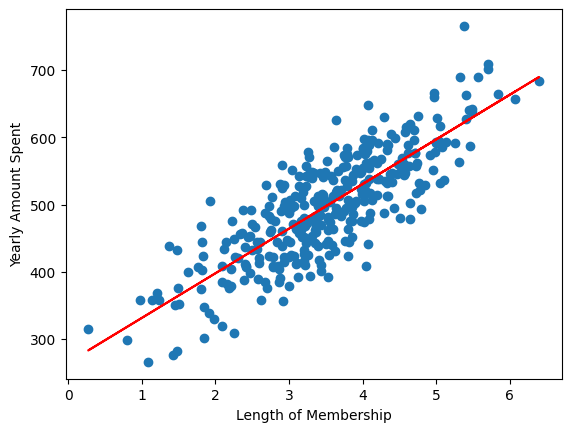

In [13]:
# Visualisasi garis regresi pada data latih
# Catatan: koefisien 265.2483 dan 66.3015 bersifat contoh dari modul,
# sebaiknya diganti dengan lr.params['const'] dan lr.params['Length of Membership']
plt.scatter(X_train, y_train)
plt.plot(X_train, lr.params['const'] + lr.params['Length of Membership'] * X_train, 'r')
plt.xlabel('Length of Membership')
plt.ylabel('Yearly Amount Spent')
plt.show()


## Langkah 7 - Analisis Residual

In [14]:
# Prediksi nilai y dari data yang telah dilatih
y_train_pred = lr.predict(X_train_sm)

# Menghitung residual
res = (y_train - y_train_pred)


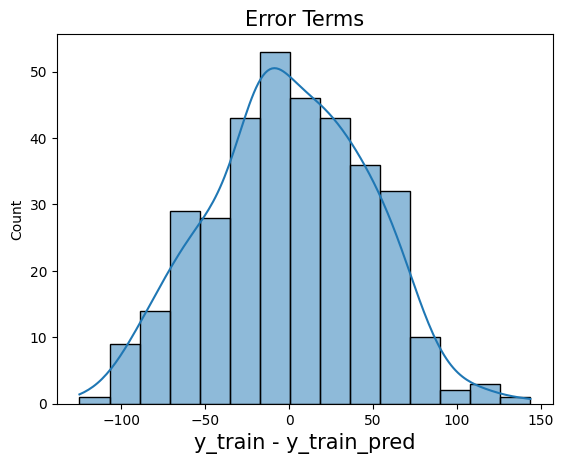

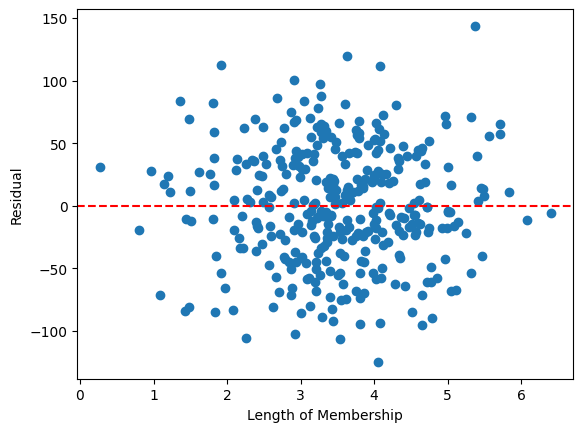

In [15]:
# Histogram residual
fig = plt.figure()
sns.histplot(res, bins=15, kde=True)
plt.title('Error Terms', fontsize=15)
plt.xlabel('y_train - y_train_pred', fontsize=15)
plt.show()

# Scatter plot residual
plt.scatter(X_train, res)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Length of Membership')
plt.ylabel('Residual')
plt.show()


## Langkah 8 - Prediksi pada Data Uji dan Evaluasi Model

In [16]:
# Prediksi pada data uji
X_test_sm = sm.add_constant(X_test)
y_test_pred = lr.predict(X_test_sm)


In [17]:
# Hitung nilai R-squared
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r_squared = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)

print('R-squared:', r_squared)
print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)


R-squared: 0.611948913768747
MAE: 36.867293139302234
MSE: 2171.370176630491
RMSE: 46.597963224056166


## Langkah 9 - Visualisasi Hasil

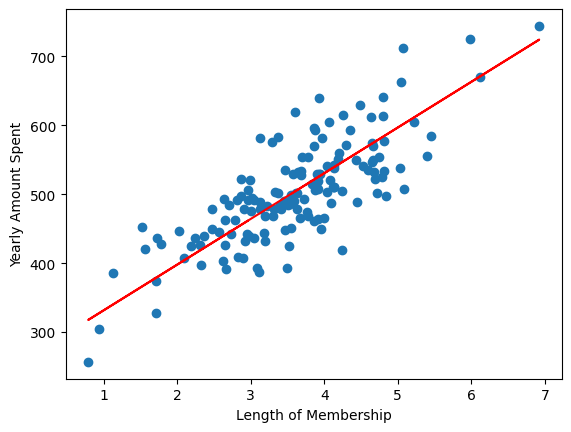

In [18]:
# Visualisasi data uji dan hasil prediksi
plt.scatter(X_test, y_test)
plt.plot(X_test, y_test_pred, 'r')
plt.xlabel('Length of Membership')
plt.ylabel('Yearly Amount Spent')
plt.show()
